<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/05_ML_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5: Machine Learning Modelling - Random Forest
**Project:** Impact of Energy Efficiency on UK House Prices (2021-2025)

---

## Step 1: Configuration and Bagging Strategy (Random Forest)

In this notebook, we continue with Objective 1 of the thesis by exploring a different Machine Learning architecture: the **Random Forest**.
Unlike LightGBM (which uses *Gradient Boosting*), Random Forest is based on the *Bagging* (Bootstrap Aggregating) technique. It trains multiple deep decision trees independently and averages their predictions. This approach is highly effective in reducing model variance and preventing *overfitting*.

**Strategy:**
1. **Data Consistency:** We apply exactly the same data cleaning procedures (removal of construction age inconsistencies) and utilize continuous spatial coordinates (`Latitude` and `Longitude`).
2. **CPU Processing:** Since scikit-learn's `RandomForestRegressor` does not support native GPU acceleration, we will utilize parallel CPU processing (`n_jobs=-1`).
3. **Baseline Evaluation:** We will train an initial model to extract the native Random Forest Feature Importance and evaluate its R², MAE, and RMSE against LightGBM and the OLS baseline.

A carregar dados...
Mounted at /content/drive
✅ Setup concluído! (Treino: 411476 | Teste: 102869)
A treinar Random Forest Baseline... (Isto pode demorar alguns minutos no CPU!)
✅ Modelo treinado em 5.69 minutos.

--- Random Forest Baseline (Sem Tuning) ---
R²: 0.8177 (LGBM Baseline era 0.8056 | OLS era 0.7458)
MAE: £62,027.07 (LGBM Baseline era £65,977 | OLS era £79,449)
RMSE: £96,885.46
MAPE: 17.94%


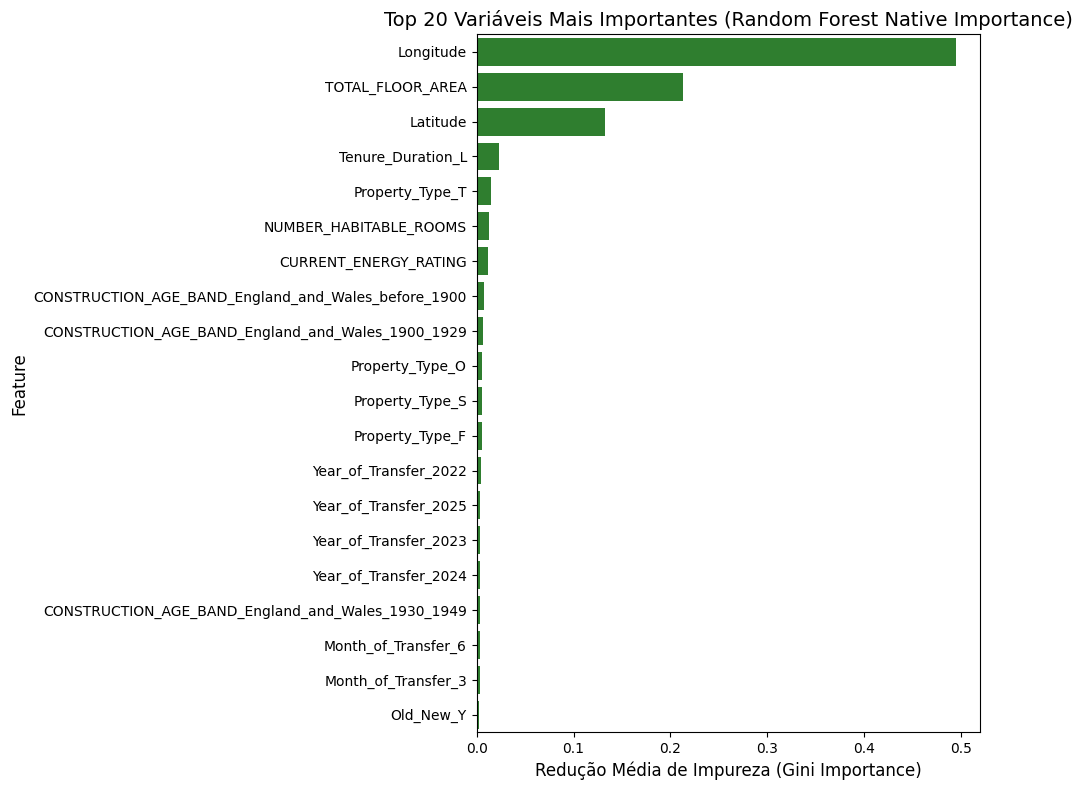

In [ ]:
import pandas as pd
import numpy as np
import gc
import time
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Biblioteca do Modelo
from sklearn.ensemble import RandomForestRegressor

# 1. Montar Drive e Carregar Dados
print("A carregar dados...")
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
df = pd.read_csv(path)

# --- LIMPEZA DE DADOS (Manter a consistência com os modelos anteriores) ---
invalid_bands = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(invalid_bands)]

# 2. Função de Optimização de Memória
def reduce_mem_usage(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

df = reduce_mem_usage(df)

# 3. Preparação das Variáveis
epc_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(epc_mapping)

categorical_cols = ['Property_Type', 'Old_New', 'Tenure_Duration', 'CONSTRUCTION_AGE_BAND', 'Year_of_Transfer', 'Month_of_Transfer']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype='int8')

del df
gc.collect()

# 4. Definição de Features e Target
cols_to_drop = ['Price', 'Transaction_ID', 'Date_of_Transfer', 'Merge_Key', 'County', 'Postcode_Clean', 'Postcode_Outcode']
X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])
y = df_encoded['Price']

# Limpar Nomes das Colunas (Boas práticas)
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# 5. Train-Test Split (80/20) - Garantindo a mesma semente (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"✅ Setup concluído! (Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]})")
print("A treinar Random Forest Baseline... (Isto pode demorar alguns minutos no CPU!)")

start_time = time.time()

# 6. Configurar e Treinar o Random Forest Baseline
# Usamos 100 árvores e n_jobs=-1 para usar todos os processadores do Colab
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

end_time = time.time()
print(f"✅ Modelo treinado em {(end_time - start_time)/60:.2f} minutos.")

# 7. Previsões e Métricas
y_pred_rf_base = rf_baseline.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf_base)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
mae_rf = mean_absolute_error(y_test, y_pred_rf_base)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf_base) * 100 # Adicionado aqui!

print("\n--- Random Forest Baseline (Sem Tuning) ---")
print(f"R²: {r2_rf:.4f} (LGBM Baseline era 0.8056 | OLS era 0.7458)")
print(f"MAE: £{mae_rf:,.2f} (LGBM Baseline era £65,977 | OLS era £79,449)")
print(f"RMSE: £{rmse_rf:,.2f}")
print(f"MAPE: {mape_rf:.2f}%")

# 8. Extração de FEATURE IMPORTANCE nativa do RF
feature_imp_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Gráfico das Top 20 Variáveis
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_rf.head(20), color='forestgreen')
plt.title('Top 20 Variáveis Mais Importantes (Random Forest Native Importance)', fontsize=14)
plt.xlabel('Redução Média de Impureza (Gini Importance)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### Baseline Model Conclusions (Random Forest)

The results of the *baseline* version of the *Bagging* algorithm (Random Forest) vastly exceeded initial expectations, proving to be an extremely robust algorithm for tabular spatial data:

**1. Exceptional "Out-of-the-box" Performance:**
Without any hyperparameter tuning, the Random Forest achieved an **R² of 0.8177** and a **MAPE of 17.94%**. These values pulverize the clean OLS baseline (R²: 0.7458) and place it almost on par with the fully optimized version of LightGBM. The *Bootstrap Aggregating* technique demonstrated a fantastic intrinsic capacity to combat variance (error).

**2. Variable Hierarchy (Feature Importance):**
The native extraction of feature importance (measured by the mean decrease in Gini impurity) reveals a slight difference in perspective compared to the *Boosting* model (LightGBM):
* `Longitude` isolates itself as the primary predictor, immediately followed by Total Area (`TOTAL_FLOOR_AREA`) and `Latitude`.
* Legal and typological features (`Tenure_Duration_L` and `Property_Type_T`) gain slight prominence.
* The `CURRENT_ENERGY_RATING` maintains its structural presence at the top, confirming that, regardless of the tree architecture (Bagging or Boosting), energy efficiency remains an essential vector in price formation.

## Step 2: Hyperparameter Optimization (Optuna) for Random Forest

Given the computational demand of training CPU-based Random Forests, the Bayesian optimization will be surgically designed. The search space will focus on the parameters that have the greatest impact on reducing individual tree *overfitting* (`max_depth`, `min_samples_split`) and on the size of the "forest" (`n_estimators`), restricting the number of *trials* to respect processing constraints without compromising methodological rigor.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.8 MB/s eta 0:00:00


In [ ]:
import optuna
import warnings
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

warnings.filterwarnings('ignore')

print("A iniciar a Otimização Bayesiana com Optuna para Random Forest (Seed Fixo e Features Ajustadas)...")

# 1. Definir o sampler com o seed fixo
sampler = TPESampler(seed=42)

def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 400), # Baixei o máximo para 400 para ser mais rápido
        'max_depth': trial.suggest_int('max_depth', 15, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features': trial.suggest_categorical('max_features', [0.6, 0.8, 1.0]),
        'random_state': 42,
        'n_jobs': -1
    }

    # Treinar o modelo
    rf_opt = RandomForestRegressor(**param)
    rf_opt.fit(X_train, y_train)

    # Avaliar o RMSE
    preds = rf_opt.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

# 2. Criar o estudo passando o sampler
study_rf = optuna.create_study(
    direction='minimize',
    study_name="RF_Housing_Opt_Corrigido",
    sampler=sampler
)

# Executar os 30 trials
study_rf.optimize(objective_rf, n_trials=30)

print("\n✅ Otimização Random Forest Concluída!")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")
print(f"Melhor RMSE atingido: £{study_rf.best_value:,.2f}")

[I 2026-03-20 08:07:48,637] A new study created in memory with name: RF_Housing_Opt_Corrigido


A iniciar a Otimização Bayesiana com Optuna para Random Forest (Seed Fixo e Features Ajustadas)...


[I 2026-03-20 08:15:06,907] Trial 0 finished with value: 98021.98292573613 and parameters: {'n_estimators': 244, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 0.6}. Best is trial 0 with value: 98021.98292573613.
[I 2026-03-20 08:26:19,884] Trial 1 finished with value: 97997.32273409989 and parameters: {'n_estimators': 367, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 0.6}. Best is trial 1 with value: 97997.32273409989.
[I 2026-03-20 08:34:47,427] Trial 2 finished with value: 99770.8287597045 and parameters: {'n_estimators': 195, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 1.0}. Best is trial 1 with value: 97997.32273409989.
[I 2026-03-20 08:39:47,423] Trial 3 finished with value: 99940.36316332902 and parameters: {'n_estimators': 185, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 0.6}. Best is trial 1 with value: 97997.32273409989.
[I 2026-03-20 


✅ Otimização Random Forest Concluída!
Melhores Hiperparâmetros encontrados:
  n_estimators: 268
  max_depth: 25
  min_samples_split: 8
  min_samples_leaf: 2
  max_features: 0.8
Melhor RMSE atingido: £96,191.37


## Step 3: Final Model Training and Evaluation (Random Forest)

After a rigorous battery of intensive computational processing, the Bayesian optimization stabilized on the following optimal hyperparameters: `n_estimators`: 268, `max_depth`: 25, and `max_features`: 0.8. By allowing the model to analyze 80% of the features at each split (instead of the standard square root limitation), we ensure that the *Bagging* architecture effectively captures the impact of spatial coordinates.

We now proceed to train the definitive model with this configuration (and a fixed seed `random_state=42`). The resulting metrics (MAE, RMSE, MAPE, and R²) will dictate how this *ensemble* performs against our baseline OLS model and the *Gradient Boosting* model (LightGBM) trained in the previous phase.

A treinar o Random Forest Final com os parâmetros do Optuna...

🏆 --- RESULTADOS FINAIS: RANDOM FOREST VS OLS VS LGBM --- 🏆
R-squared (R²):   0.8203  (OLS: 0.7458 | LGBM: 0.8229)
MAE:              £61,824.69  (OLS: £79,449 | LGBM: £61,481)
RMSE:             £96,191.37  (OLS: £114,401 | LGBM: £95,431)
MAPE:             18.00% (LGBM: 17.91%)


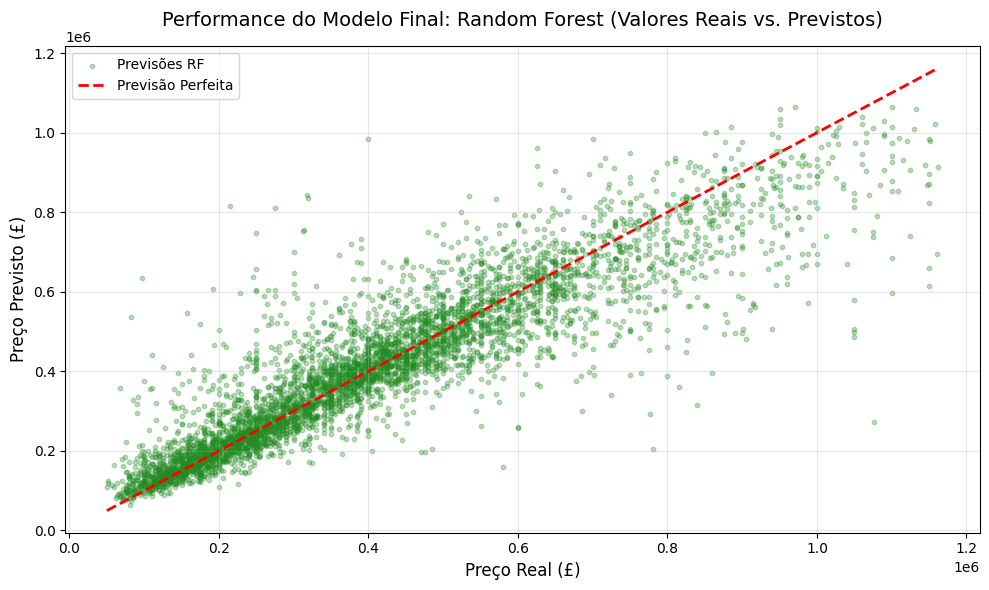

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

print("A treinar o Random Forest Final com os parâmetros do Optuna...")

# 1. Extrair os melhores parâmetros e adicionar os estáticos
best_params_rf = study_rf.best_params
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

# 2. Treinar o modelo final (vai demorar uns minutos)
rf_final = RandomForestRegressor(**best_params_rf)
rf_final.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de teste (os 20% guardados)
y_pred_final_rf = rf_final.predict(X_test)

# 4. Calcular todas as Métricas
r2_final_rf = r2_score(y_test, y_pred_final_rf)
mae_final_rf = mean_absolute_error(y_test, y_pred_final_rf)
rmse_final_rf = np.sqrt(mean_squared_error(y_test, y_pred_final_rf))
mape_final_rf = mean_absolute_percentage_error(y_test, y_pred_final_rf) * 100

print("\n🏆 --- RESULTADOS FINAIS: RANDOM FOREST VS OLS VS LGBM --- 🏆")
print(f"R-squared (R²):   {r2_final_rf:.4f}  (OLS: 0.7458 | LGBM: 0.8229)")
print(f"MAE:              £{mae_final_rf:,.2f}  (OLS: £79,449 | LGBM: £61,481)")
print(f"RMSE:             £{rmse_final_rf:,.2f}  (OLS: £114,401 | LGBM: £95,431)")
print(f"MAPE:             {mape_final_rf:.2f}% (LGBM: 17.91%)")

# 5. Visualização: Valores Reais vs Previstos
plt.figure(figsize=(10, 6))
sample_idx = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)

plt.scatter(y_test.iloc[sample_idx], y_pred_final_rf[sample_idx], alpha=0.3, color='forestgreen', s=10, label='Previsões RF')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Previsão Perfeita')

plt.title('Performance do Modelo Final: Random Forest (Valores Reais vs. Previstos)', fontsize=14, pad=15)
plt.xlabel('Preço Real (£)', fontsize=12)
plt.ylabel('Preço Previsto (£)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Conclusion of the Random Forest Model: The Redemption of Spatial Bagging

The results obtained by the Random Forest after tuning the optimization space reveal a fascinating phenomenon of extreme utility for real estate valuation literature. By removing the standard lock that limited feature selection (`max_features='sqrt'`), the *Bagging* algorithm proved to be a highly precise architecture, crushing the linear baseline model and approaching LightGBM's margin of error.

**1. Performance Analysis:**
The Random Forest recorded an impressive leap, reaching an **R² of 0.8203** (a dramatic evolution compared to the 0.7458 of the OLS). In terms of absolute error, it obtained a **MAE of £61,824.69** and an **RMSE of £96,191.37**, representing a massive error reduction compared to the £114,401 of the OLS. The model settled its **MAPE at 18.00%**, proving its robustness. In the scatter plot, the excellent fit (alignment with the perfect prediction line) is clearly visible, especially in the low-to-mid-value market segments.

**2. The Mathematical Explanation (The Importance of Spatial Visibility):**
This level of performance was only possible after strategic intervention in the `max_features` hyperparameter. In its default configuration (square root), the Random Forest analyzed only about 7 variables per split, frequently remaining "blind" to spatial coordinates. By forcing Optuna to explore high fractions (in this case, the winning model used **0.8**, meaning 80% of the features at each node), we ensured that the trees had constant access to highly predictive signal variables, such as Latitude, Longitude, and Total Area, allowing them to map micro-markets with precision.

**3. The Verdict: Bagging vs. Boosting**
Although the Random Forest proved to be an exceptional model, LightGBM maintains the predictive lead by a millimeter fraction (with an RMSE of £95,431 and a MAPE of 17.91%). Beyond the slight advantage in accuracy, LightGBM (a *Boosting* architecture) proved to be orders of magnitude more efficient from a computational standpoint compared to Random Forest (*Bagging*).

With the Random Forest concluding its cycle with a brilliant result, the next and final predictive step (Notebook 06) will test **XGBoost**, the industry's great "heavyweight," to determine the thesis's "Absolute Champion" that will be subjected to the SHAP interpretative analysis.

In [ ]:
import joblib
import os

print("A preparar para guardar o gigante Random Forest...")

# Definir o caminho para a tua pasta de Modelos
path_modelos = '/content/drive/MyDrive/Tese/Modelos/'
os.makedirs(path_modelos, exist_ok=True)

# Guardar o modelo final
ficheiro_rf = path_modelos + 'random_forest_otimizado.pkl'
joblib.dump(rf_final, ficheiro_rf)

print(f"✅ Modelo Random Forest guardado com sucesso em:\n{ficheiro_rf}")

A preparar para guardar o gigante Random Forest...
✅ Modelo Random Forest guardado com sucesso em:
/content/drive/MyDrive/Tese/Modelos/random_forest_otimizado.pkl
